# EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and SWA

This notebook trains an EfficientNet-B0 model combining three techniques:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- **SWA (Stochastic Weight Averaging)**: Averages weights from different training stages for better generalization

In [2]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from torch.optim.swa_utils import AveragedModel, SWALR
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../../..')
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [3]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# SWA parameters
swa_start = 30  # Start SWA after epoch 30
swa_lr = 1e-4   # SWA learning rate

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-swa.pth'
swa_model_path = 'models/b0-entropy-ordinal-swa-averaged.pth'
log_path = 'logs/b0-entropy-ordinal-swa.txt'

Using device: cuda


## Ordinal Loss Function

Ordinal regression treats the problem as a series of binary classifications:
- For ISUP grade k, we predict k binary labels: [1,1,...,1,0,0,...,0]
- Example: ISUP 2 → [1, 1, 0, 0, 0] (grade > 0, grade > 1, but not > 2, > 3, > 4)

In [4]:
class OrdinalRegressionLoss(nn.Module):
    """
    Ordinal regression loss for ordered categories.
    
    For each sample with grade k, we create k binary labels:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    """
    def __init__(self):
        super(OrdinalRegressionLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        return self.bce(logits, targets)

def encode_ordinal_labels(labels, num_classes=5):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of ISUP grades (0-5)
        num_classes: Number of thresholds (5 for ISUP 0-5)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    # Convert to numpy if tensor
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)  # Convert to int
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(logits)
    
    # Sum probabilities > 0.5 to get predicted grade
    predictions = (probs > 0.5).sum(dim=1)
    
    return predictions

# Initialize loss function
loss_function = OrdinalRegressionLoss()
print("Ordinal Regression Loss initialized")

Ordinal Regression Loss initialized


## Load Data with Entropy Filtering

In [5]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [6]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [7]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2358
Validation batches: 589
Test batches: 530


## Model Setup with SWA

In [8]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

# Create SWA model
swa_model = AveragedModel(model)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")
print(f"SWA will start at epoch {swa_start}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6
SWA will start at epoch 30


## Optimizer and Scheduler

In [9]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

# SWA scheduler
swa_scheduler = SWALR(optimizer, swa_lr=swa_lr)

print("Optimizer and schedulers configured")

Optimizer and schedulers configured


## Training and Validation Functions

In [10]:
def training_step(model, dataloader, optimizer, device, loss_fn, use_swa=False, swa_model=None):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    # Update SWA model if in SWA phase
    if use_swa and swa_model is not None:
        swa_model.update_parameters(model)
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn, model_name="Model"):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc=f"Validation ({model_name})")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop with SWA

In [11]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': [],
    'swa_val_kappa': []  # Track SWA model kappa
}

print("\nStarting training...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Check if we should use SWA
    use_swa = epoch >= swa_start
    
    if use_swa and epoch == swa_start:
        print("\n🔄 Starting Stochastic Weight Averaging (SWA)\n")
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function, 
                               use_swa=use_swa, swa_model=swa_model)
    
    # Validate regular model
    metrics = validation_step(model, valid_loader, device, loss_function, "Regular")
    
    # Update scheduler
    if use_swa:
        swa_scheduler.step()
    else:
        scheduler.step()
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults (Regular Model):")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Validate SWA model if in SWA phase
    if use_swa:
        # Update batch normalization statistics for SWA model
        torch.optim.swa_utils.update_bn(train_loader, swa_model, device=device)
        
        swa_metrics = validation_step(swa_model, valid_loader, device, loss_function, "SWA")
        history['swa_val_kappa'].append(swa_metrics['val_kappa'])
        
        print(f"\nResults (SWA Model):")
        print(f"  Val Accuracy: {swa_metrics['val_acc']*100:.2f}%")
        print(f"  Val Kappa: {swa_metrics['val_kappa']:.4f}")
        print(f"  Val F1: {swa_metrics['val_f1']:.4f}")
        
        # Use SWA model kappa for best model selection during SWA phase
        current_kappa = swa_metrics['val_kappa']
    else:
        current_kappa = metrics['val_kappa']
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}"
    if use_swa:
        log_line += f" | swa_kappa: {swa_metrics['val_kappa']:.4f}"
    log_line += "\n"
    
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if current_kappa > best_kappa:
        best_kappa = current_kappa
        best_epoch = epoch
        epochs_without_improvement = 0
        
        # Save the appropriate model
        if use_swa:
            torch.save(swa_model.state_dict(), swa_model_path)
            print(f"\n  ✓ Best SWA model saved! Kappa: {best_kappa:.4f}")
        else:
            torch.save(model.state_dict(), model_path)
            print(f"\n  ✓ Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training...


Epoch 1/50
--------------------------------------------------------------------------------


Validation (Regular): 100%|██████████| 589/589 [01:32<00:00,  6.35it/s]



Results (Regular Model):
  Train Loss: 0.40323
  Val Loss: 0.29158
  Val Accuracy: 57.89%
  Val Kappa: 0.7738
  Val F1: 0.5028
  Learning Rate: 0.0003000

  ✓ Best model saved! Kappa: 0.7738

Epoch 2/50
--------------------------------------------------------------------------------


Validation (Regular): 100%|██████████| 589/589 [01:32<00:00,  6.35it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results (Regular Model):
  Train Loss: 0.33299
  Val Loss: 0.26421
  Val Accuracy: 61.74%
  Val Kappa: 0.8024
  Val F1: 0.5359
  Learning Rate: 0.0003003

  ✓ Best model saved! Kappa: 0.8024

Epoch 3/50
--------------------------------------------------------------------------------


...


Results (Regular Model):
  Train Loss: 0.18830
  Val Loss: 0.23166
  Val Accuracy: 65.53%
  Val Kappa: 0.8566
  Val F1: 0.6063
  Learning Rate: 0.0002438

  No improvement for 5 epoch(s)

Epoch 17/50
--------------------------------------------------------------------------------


Validation (Regular): 100%|██████████| 589/589 [01:37<00:00,  6.02it/s]



Results (Regular Model):
  Train Loss: 0.18477
  Val Loss: 0.26783
  Val Accuracy: 60.33%
  Val Kappa: 0.8286
  Val F1: 0.5485
  Learning Rate: 0.0002361

  No improvement for 6 epoch(s)

Epoch 18/50
--------------------------------------------------------------------------------


Validation (Regular): 100%|██████████| 589/589 [01:39<00:00,  5.90it/s]


Results (Regular Model):
  Train Loss: 0.17775
  Val Loss: 0.23951
  Val Accuracy: 66.89%
  Val Kappa: 0.8510
  Val F1: 0.6042
  Learning Rate: 0.0002280

  No improvement for 7 epoch(s)

Early stopping at epoch 18
Best epoch: 11 with Kappa: 0.8589

Training completed!
Best validation Kappa: 0.8589 at epoch 11


## Plot Training History

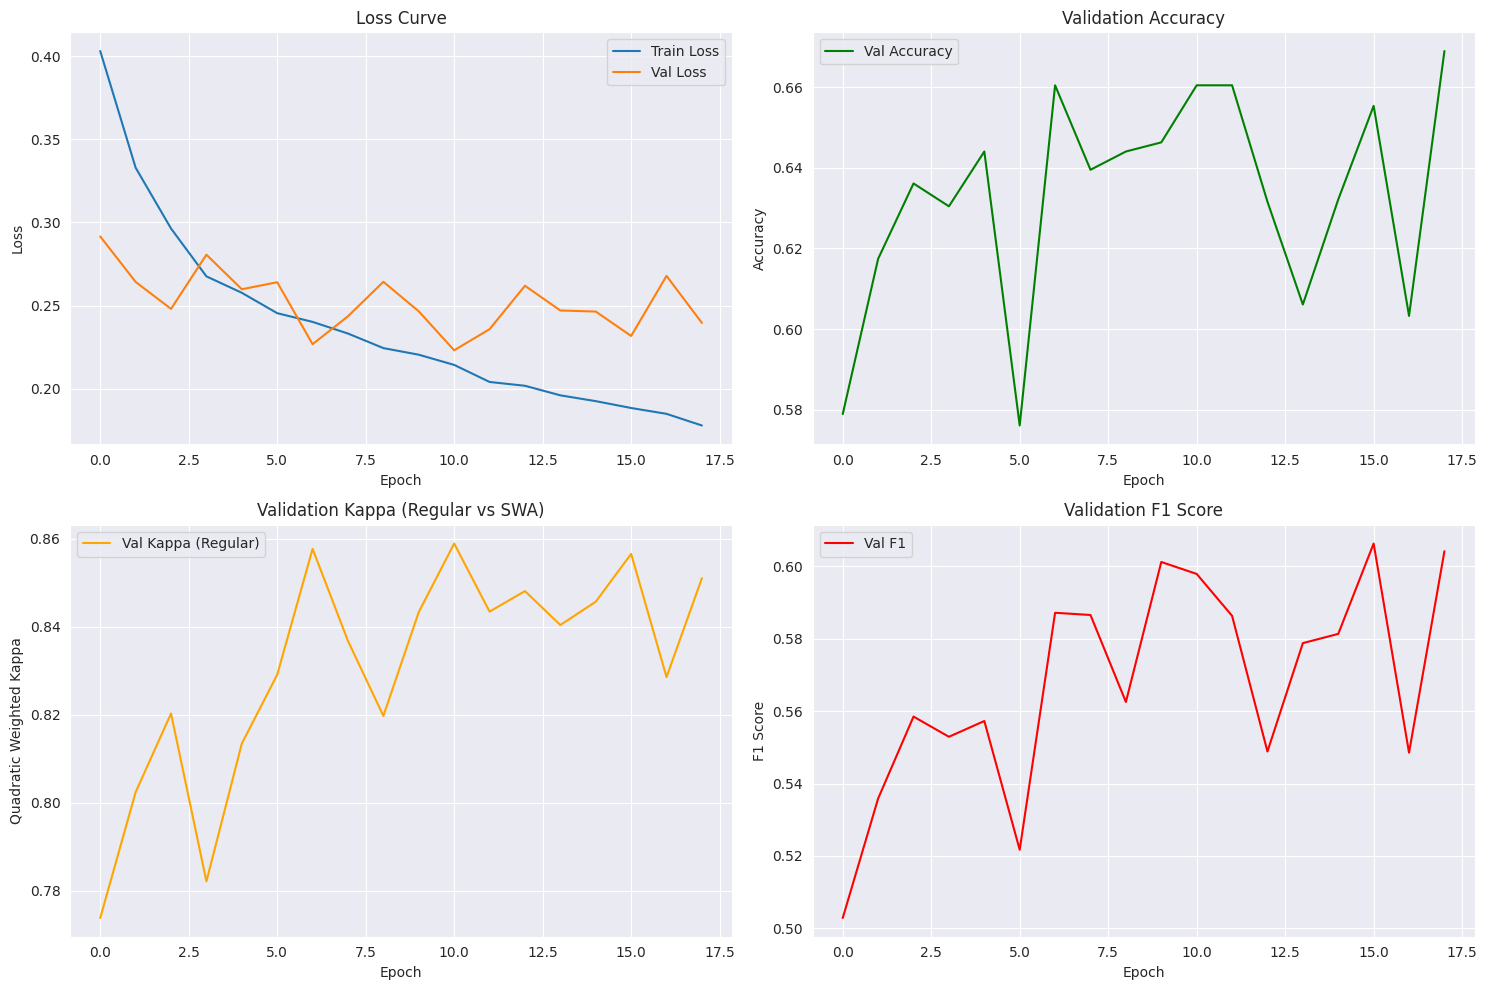

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
if swa_start < len(history['train_loss']):
    axes[0, 0].axvline(x=swa_start-1, color='red', linestyle='--', label='SWA Start')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
if swa_start < len(history['val_acc']):
    axes[0, 1].axvline(x=swa_start-1, color='red', linestyle='--', label='SWA Start')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa (Regular)', color='orange')
if len(history['swa_val_kappa']) > 0:
    swa_epochs = list(range(swa_start, swa_start + len(history['swa_val_kappa'])))
    axes[1, 0].plot(swa_epochs, history['swa_val_kappa'], label='Val Kappa (SWA)', color='blue', linewidth=2)
if swa_start < len(history['val_kappa']):
    axes[1, 0].axvline(x=swa_start-1, color='red', linestyle='--', label='SWA Start')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa (Regular vs SWA)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
if swa_start < len(history['val_f1']):
    axes[1, 1].axvline(x=swa_start-1, color='red', linestyle='--', label='SWA Start')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-swa-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Loading best regular model...

Evaluating Regular model on test set...



Testing: 100%|██████████| 530/530 [01:29<00:00,  5.95it/s]



TEST SET RESULTS (Regular Model)
Accuracy: 65.35%
Quadratic Weighted Kappa: 0.8523
Macro F1 Score: 0.5914

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.8521    0.8894    0.8703       434
      ISUP 1     0.7254    0.7200    0.7227       400
      ISUP 2     0.4914    0.4300    0.4587       200
      ISUP 3     0.4142    0.3784    0.3955       185
      ISUP 4     0.4279    0.5080    0.4645       187
      ISUP 5     0.6552    0.6196    0.6369       184

    accuracy                         0.6535      1590
   macro avg     0.5944    0.5909    0.5914      1590
weighted avg     0.6512    0.6535    0.6514      1590


Confusion Matrix:
[[386  37   2   4   5   0]
 [ 42 288  55  14   1   0]
 [  3  47  86  51  12   1]
 [  7   8  22  70  62  16]
 [ 11  11   8  19  95  43]
 [  4   6   2  11  47 114]]


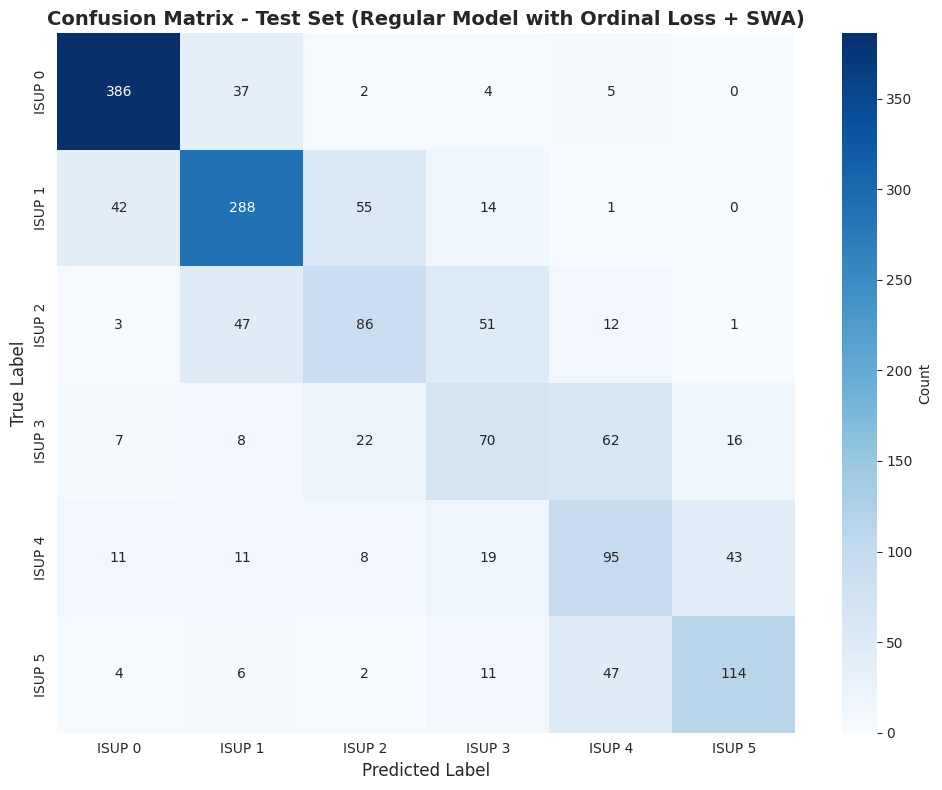

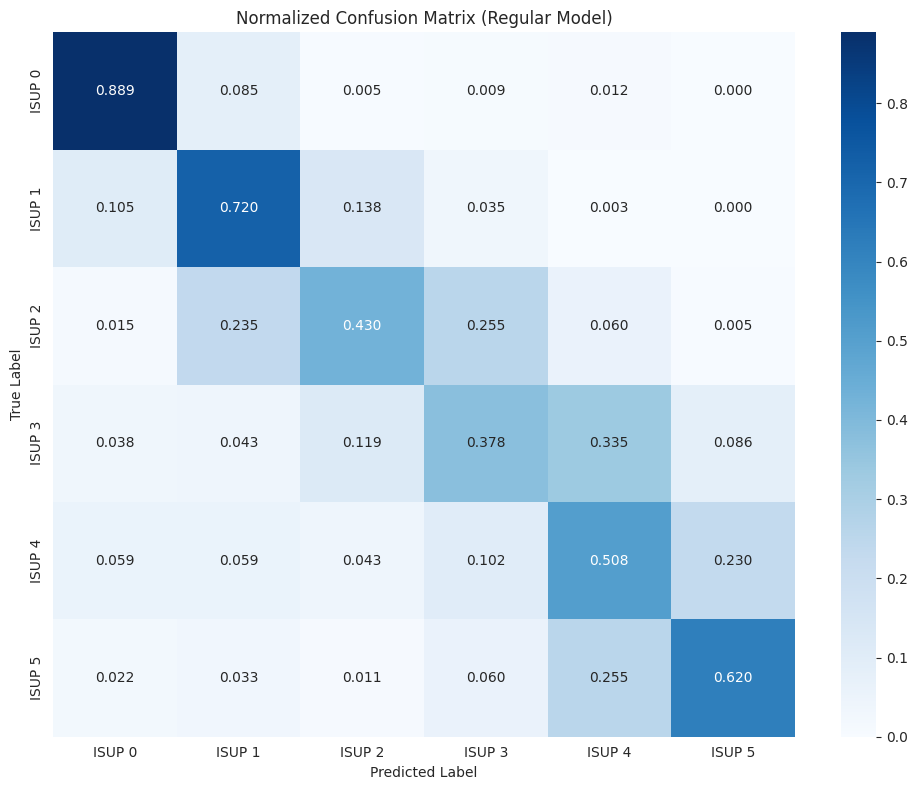


Test results saved to logs/b0-entropy-ordinal-swa-test-results.txt


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model (SWA if it was used)
if best_epoch >= swa_start:
    print("Loading best SWA model...")
    swa_model.load_state_dict(torch.load(swa_model_path, weights_only=True))
    eval_model = swa_model
    model_type = "SWA"
else:
    print("Loading best regular model...")
    model.load_state_dict(torch.load(model_path, weights_only=True))
    eval_model = model
    model_type = "Regular"

eval_model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print(f"\nEvaluating {model_type} model on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = eval_model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print(f"TEST SET RESULTS ({model_type} Model)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix - Test Set ({model_type} Model with Ordinal Loss + SWA)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-swa-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)]
)
plt.title(f"Normalized Confusion Matrix ({model_type} Model)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-swa-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('logs/b0-entropy-ordinal-swa-test-results.txt', 'w') as f:
    f.write(f"EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and SWA ({model_type} Model)\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-swa-test-results.txt")

## Summary

This notebook trained EfficientNet-B0 combining three powerful techniques:
1. **Entropy filtering** - Removed high-entropy samples for cleaner training data
2. **Ordinal loss** - Leveraged the ordered nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
3. **Stochastic Weight Averaging (SWA)** - Averaged model weights from different training stages for flatter minima and better generalization

The combination of these techniques should provide:
- Better data quality (entropy filtering)
- More appropriate loss function for ordinal tasks (ordinal loss)
- Improved generalization and robustness (SWA)